<a href="https://colab.research.google.com/github/uxntani/AI-LAB/blob/main/Lab1-Problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

BFS traversal : A -> B -> C -> D -> E -> F
DFS traversal : A -> B -> D -> E -> C -> F


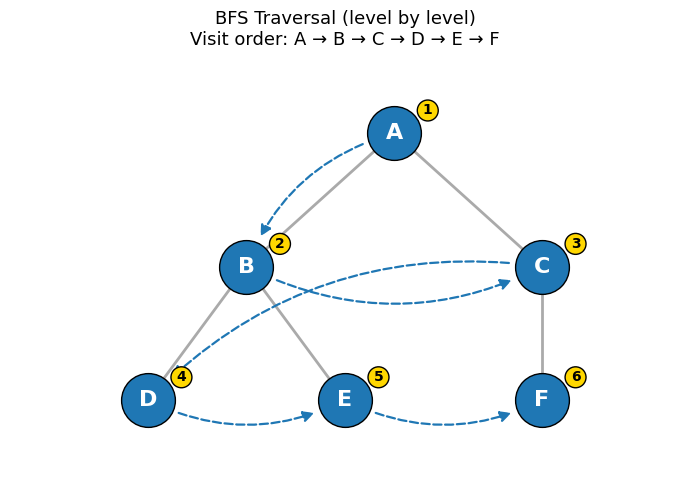

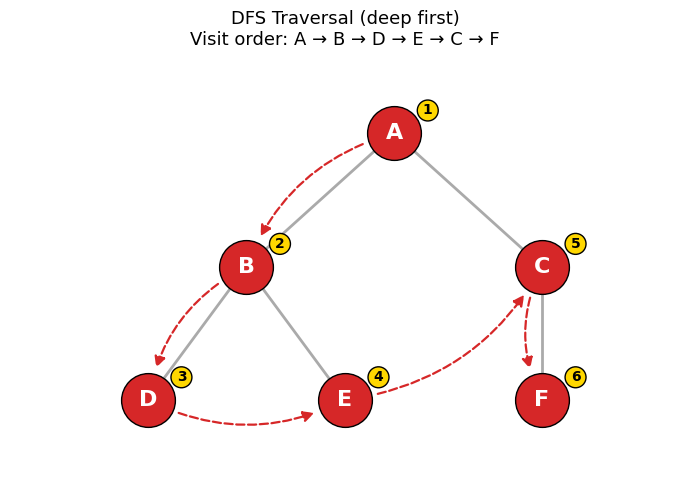

In [2]:
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

graph = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F"],
    "D": [],
    "E": [],
    "F": [],
}

def bfs(graph, start):
    visited = {start}
    order = []
    queue = deque([start])
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)
    return order

def dfs(graph, node, visited=None, order=None):
    if visited is None:
        visited, order = set(), []
    visited.add(node)
    order.append(node)
    for neighbour in graph[node]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited, order)
    return order

def tree_layout(graph, root):
    pos = {}
    next_leaf_x = [0]
    def place(node, depth):
        children = graph[node]
        if not children:
            x = next_leaf_x[0]
            next_leaf_x[0] += 1
        else:
            xs = [place(child, depth + 1) for child in children]
            x = sum(xs) / len(xs)
        pos[node] = (x, -depth)
        return x
    place(root, 0)
    return pos

def draw_traversal(graph, root, order, title, filename, colour):
    pos = tree_layout(graph, root)
    fig, ax = plt.subplots(figsize=(7, 5))
    for parent, children in graph.items():
        for child in children:
            (x1, y1), (x2, y2) = pos[parent], pos[child]
            ax.plot([x1, x2], [y1, y2], color="#aaaaaa", lw=2, zorder=1)
    for a, b in zip(order, order[1:]):
        ax.add_patch(
            FancyArrowPatch(
                pos[a], pos[b],
                connectionstyle="arc3,rad=0.25",
                arrowstyle="-|>", mutation_scale=16,
                color=colour, lw=1.6, linestyle="--",
                shrinkA=24, shrinkB=24, zorder=2,
            )
        )
    for step, node in enumerate(order, start=1):
        x, y = pos[node]
        ax.scatter(x, y, s=1500, color=colour, edgecolor="black", zorder=3)
        ax.text(x, y, node, ha="center", va="center",
                fontsize=16, fontweight="bold", color="white", zorder=4)
        ax.text(x + 0.17, y + 0.17, str(step), ha="center", va="center",
                fontsize=10, fontweight="bold", zorder=5,
                bbox=dict(boxstyle="circle,pad=0.25", fc="gold", ec="black"))
    ax.set_title(f"{title}\nVisit order: {' → '.join(order)}", fontsize=13)
    ax.set_xlim(-0.7, max(x for x, _ in pos.values()) + 0.7)
    ax.set_ylim(min(y for _, y in pos.values()) - 0.6, 0.6)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    return fig
if __name__ == "__main__":
    bfs_order = bfs(graph, "A")
    dfs_order = dfs(graph, "A")
    print("BFS traversal :", " -> ".join(bfs_order))
    print("DFS traversal :", " -> ".join(dfs_order))
    draw_traversal(graph, "A", bfs_order, "BFS Traversal (level by level)", "bfs_tree.png", "#1f77b4")
    draw_traversal(graph, "A", dfs_order, "DFS Traversal (deep first)", "dfs_tree.png", "#d62728")
plt.show()